# 【そこのマーケ担当者さん】とりあえずMMMをやってみよう！

Googleの **Meridian** と公式シミュレーションデータを使い、MMMを最後まで動かします。

このNotebookで行うことは次の5つです。

1. データを読み込む  
2. 簡単な探索的データ分析を行う  
3. Meridianのモデルを設定する  
4. MCMCサンプリングを実行する  
5. 貢献度・ROI・応答曲線・予算最適化を見る  

## 0. 実行前の準備

Colabのメニューから、次の設定を行ってください。

**ランタイム → ランタイムのタイプを変更 → T4 GPU**

最初のインストールセルを実行後、Colabから再起動を求められた場合だけランタイムを再起動し、その後は「1. ライブラリを読み込む」から順に実行します。

In [1]:
# 最後まで動作したNotebookと同じMeridian 1.7.0に固定します
!pip install -q 'google-meridian[and-cuda]==1.7.0'

# バージョン確認
!python3 -c "import meridian; print('Meridian version:', meridian.__version__)"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.6/503.6 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 73.6 MB/s eta 0:00:00
2026-07-16 16:51:24.790557: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Meridian version: 1.7.0


## 1. 必要なライブラリを読み込む

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_probability as tfp

import meridian
from meridian import constants
from meridian.data import load
from meridian.model import model
from meridian.model import spec
from meridian.model import prior_distribution
from meridian.analysis import optimizer
from meridian.analysis import visualizer

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("Meridian version:", meridian.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

if not tf.config.list_physical_devices("GPU"):
    raise RuntimeError(
        "GPUが有効ではありません。Colabのランタイム設定でT4 GPUを選択してください。"
    )

Meridian version: 1.7.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. 分析データを読み込む

今回はGoogleが公開している地域別・週別のシミュレーションデータを使用します。

主な列は次のとおりです。

- `conversions`：KPI
- `revenue_per_conversion`：1コンバージョンあたりの収益
- `Channel0〜4_impression`：広告のインプレッション
- `Channel0〜4_spend`：広告費
- `competitor_sales_control`：競合売上のコントロール変数
- `sentiment_score_control`：センチメントのコントロール変数
- `Promo`：非メディア施策
- `population`：地域人口

In [3]:
DATA_URL = (
    "https://raw.githubusercontent.com/google/meridian/"
    "refs/heads/main/meridian/data/simulated_data/csv/"
    "geo_all_channels.csv"
)

df = pd.read_csv(DATA_URL)

print("データサイズ:", df.shape)
display(df.head())

データサイズ: (6240, 20)


,Unnamed: 0,geo,time,Channel0_impression,Channel1_impression,Channel2_impression,Channel3_impression,Channel4_impression,competitor_sales_control,sentiment_score_control,Channel0_spend,Channel1_spend,Channel2_spend,Channel3_spend,Channel4_spend,Organic_channel0_impression,Promo,conversions,revenue_per_conversion,population
0,0,Geo0,2021-01-25,280668,0,0,470611,108010,-1.338765,0.115581,2058.0608,0.00000,0.00000,3667.3965,841.6044,97320,0.000000,1954576.8,0.020055,136670.94
1,1,Geo0,2021-02-01,366206,182108,19825,527702,252506,0.893645,0.944224,2685.2874,1755.74540,147.31808,4112.2974,1967.5044,201441,0.000000,2064249.6,0.020103,136670.94
2,2,Geo0,2021-02-08,197565,230170,0,393618,184061,-0.284549,-1.290579,1448.6895,2219.12230,0.00000,3067.4023,1434.1870,0,0.683819,2086382.8,0.019929,136670.94
3,3,Geo0,2021-02-15,140990,66643,0,326034,201729,-1.034740,-1.084514,1033.8406,642.52057,0.00000,2540.7310,1571.8545,0,1.289055,2826431.5,0.019987,136670.94
4,4,Geo0,2021-02-22,399116,164991,0,381982,153973,-0.319276,-0.017503,2926.6072,1590.71640,0.00000,2976.7249,1199.7440,0,0.227739,3551929.2,0.020000,136670.94


In [4]:
# モデル投入前の最低限のデータチェック
required_columns = [
    "geo",
    "time",
    "conversions",
    "revenue_per_conversion",
    "population",
    "competitor_sales_control",
    "sentiment_score_control",
    "Promo",
    "Organic_channel0_impression",
    *[f"Channel{i}_impression" for i in range(5)],
    *[f"Channel{i}_spend" for i in range(5)],
]

missing_columns = sorted(set(required_columns) - set(df.columns))

if missing_columns:
    raise ValueError(f"不足している列: {missing_columns}")

print("対象期間:", df["time"].min(), "〜", df["time"].max())
print("地域数:", df["geo"].nunique())
print("欠損値:", int(df[required_columns].isna().sum().sum()))
print("地域×時点の重複:", int(df.duplicated(["geo", "time"]).sum()))

対象期間: 2021-01-25 〜 2024-01-15
地域数: 40
欠損値: 0
地域×時点の重複: 0


## 3. 簡単な探索的データ分析

いきなりモデルへ入れる前に、収益・広告費・インプレッションの時系列を確認します。

ここでは「急な欠損や異常値がないか」「集計単位を間違えていないか」を見る程度に留めます。

In [5]:
df["time_dt"] = pd.to_datetime(df["time"])
df["revenue"] = df["conversions"] * df["revenue_per_conversion"]

impression_cols = [f"Channel{i}_impression" for i in range(5)]
spend_cols = [f"Channel{i}_spend" for i in range(5)]

df["total_impressions"] = df[impression_cols].sum(axis=1)
df["total_spend"] = df[spend_cols].sum(axis=1)

weekly = (
    df.groupby("time_dt", as_index=False)
    .agg(
        revenue=("revenue", "sum"),
        conversions=("conversions", "sum"),
        impressions=("total_impressions", "sum"),
        spend=("total_spend", "sum"),
    )
)

display(weekly.head())

,time_dt,revenue,conversions,impressions,spend
0,2021-01-25,7.731975e+06,386300926.3,181144632,1.408305e+06
1,2021-02-01,7.104532e+06,355303931.3,192808092,1.534845e+06
2,2021-02-08,8.762589e+06,438308889.8,145242689,1.159611e+06
3,2021-02-15,8.363356e+06,418612413.7,159670444,1.245330e+06
4,2021-02-22,7.109799e+06,355785298.0,213405785,1.670749e+06


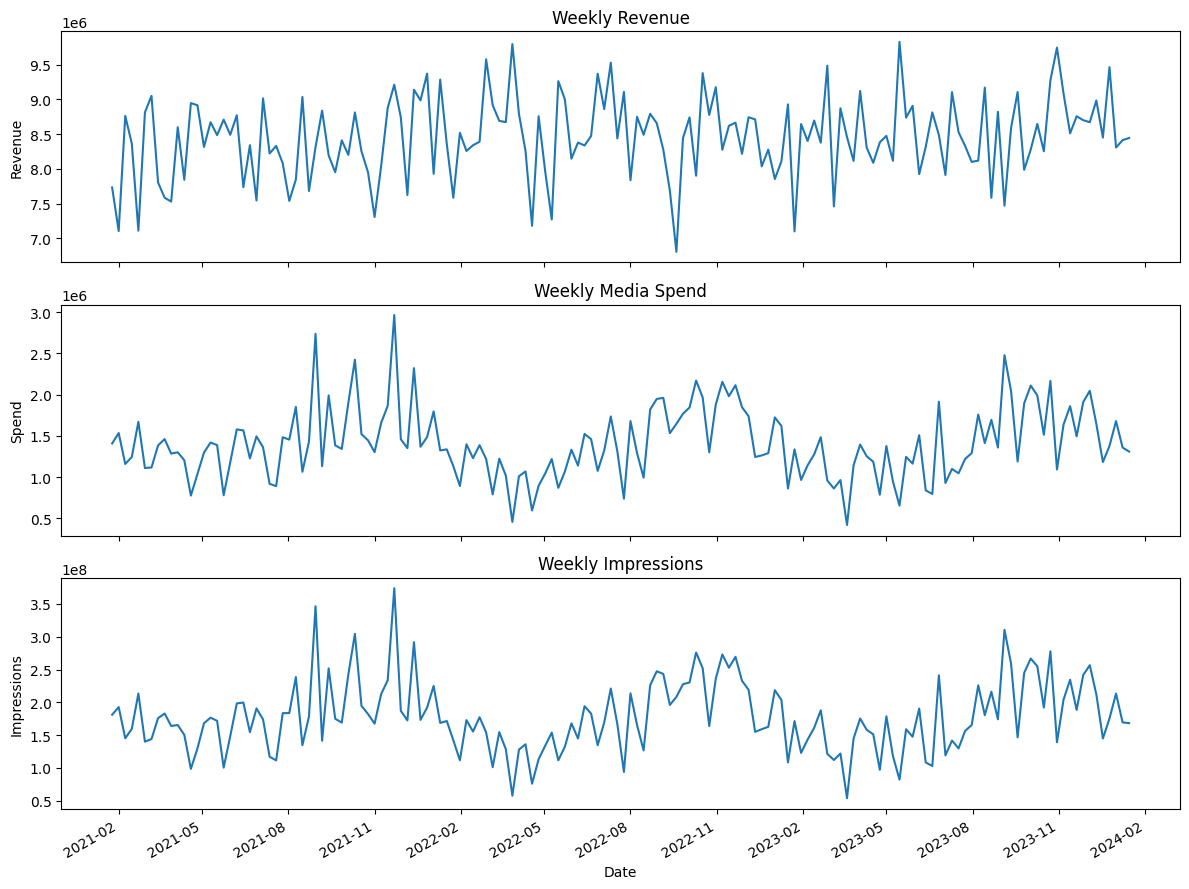

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(weekly["time_dt"], weekly["revenue"])
axes[0].set_title("Weekly Revenue")
axes[0].set_ylabel("Revenue")

axes[1].plot(weekly["time_dt"], weekly["spend"])
axes[1].set_title("Weekly Media Spend")
axes[1].set_ylabel("Spend")

axes[2].plot(weekly["time_dt"], weekly["impressions"])
axes[2].set_title("Weekly Impressions")
axes[2].set_ylabel("Impressions")
axes[2].set_xlabel("Date")

axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 4. Meridianが読み取れる形へ変換する

ここからは、最後まで動作した講義Notebookと同じく、`CoordToColumns`と`DataFrameDataLoader`を使います。

どの列がKPI・広告・広告費・コントロール変数なのかをMeridianへ伝えます。

In [7]:
coord_to_columns = load.CoordToColumns(
    time="time",
    geo="geo",
    controls=[
        "competitor_sales_control",
        "sentiment_score_control",
    ],
    population="population",
    kpi="conversions",
    revenue_per_kpi="revenue_per_conversion",
    media=[
        "Channel0_impression",
        "Channel1_impression",
        "Channel2_impression",
        "Channel3_impression",
        "Channel4_impression",
    ],
    media_spend=[
        "Channel0_spend",
        "Channel1_spend",
        "Channel2_spend",
        "Channel3_spend",
        "Channel4_spend",
    ],
    organic_media=["Organic_channel0_impression"],
    non_media_treatments=["Promo"],
)

media_to_channel = {
    "Channel0_impression": "Channel0",
    "Channel1_impression": "Channel1",
    "Channel2_impression": "Channel2",
    "Channel3_impression": "Channel3",
    "Channel4_impression": "Channel4",
}

media_spend_to_channel = {
    "Channel0_spend": "Channel0",
    "Channel1_spend": "Channel1",
    "Channel2_spend": "Channel2",
    "Channel3_spend": "Channel3",
    "Channel4_spend": "Channel4",
}

In [8]:
loader = load.DataFrameDataLoader(
    df=df,
    coord_to_columns=coord_to_columns,
    kpi_type="non_revenue",
    media_to_channel=media_to_channel,
    media_spend_to_channel=media_spend_to_channel,
)

data = loader.load()

print("地域数:", len(data.geo))
print("時点数:", len(data.time))
print("有料メディア:", list(data.media_channel.values))

地域数: 40
時点数: 156
有料メディア: ['Channel0', 'Channel1', 'Channel2', 'Channel3', 'Channel4']


## 5. モデルを設定する

今回は、各チャネルのROIについて対数正規分布の事前分布を設定します。

また、モデルの汎化性能を確認するため、各地域の約20%の時点をホールドアウトします。

In [9]:
build_media_channel_args = data.get_paid_media_channels_argument_builder()

roi_m = build_media_channel_args(
    Channel0=(0.2, 0.7),
    Channel1=(0.2, 0.7),
    Channel2=(0.3, 0.9),
    Channel3=(0.4, 0.6),
    Channel4=(0.3, 0.7),
)

roi_m_mu, roi_m_sigma = zip(*roi_m)

prior = prior_distribution.PriorDistribution(
    roi_m=tfp.distributions.LogNormal(
        roi_m_mu,
        roi_m_sigma,
        name=constants.ROI_M,
    )
)

In [10]:
np.random.seed(1)

test_pct = 0.2
n_geos = len(data.geo)
n_times = len(data.time)

holdout_id = np.full([n_geos, n_times], False)

for i in range(n_geos):
    holdout_id[
        i,
        np.random.choice(
            n_times,
            int(np.round(test_pct * n_times)),
        ),
    ] = True

print("ホールドアウトされた観測数:", int(holdout_id.sum()))

ホールドアウトされた観測数: 1128


In [11]:
model_spec = spec.ModelSpec(
    prior=prior,
    holdout_id=holdout_id,
)

mmm = model.Meridian(
    input_data=data,
    model_spec=model_spec,
)

print("モデルを作成しました。")

モデルを作成しました。


## 6. MCMCサンプリングを実行する

Meridianは、NUTSを用いたMCMCサンプリングによって事後分布を推定します。

以下は、元Notebookで最後まで収束した設定です。処理には時間がかかります。

In [12]:
%%time

mmm.sample_prior(500)

mmm.sample_posterior(
    n_chains=3,
    n_adapt=500,
    n_burnin=500,
    n_keep=1000,
)

CPU times: user 9min 47s, sys: 16.8 s, total: 10min 4s
Wall time: 9min 49s


/usr/local/lib/python3.12/dist-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(


## 7. モデルが収束したか確認する

結果を読む前に、まずR-hatを確認します。

R-hatが1に近く、概ね1.1未満であることが一つの目安です。

In [13]:
model_diagnostics = visualizer.ModelDiagnostics(mmm)
model_diagnostics.plot_rhat_boxplot()

alt.LayerChart(...)

In [14]:
# R²・MAPE・wMAPEを確認
model_diagnostics.predictive_accuracy_table()

,metric,geo_granularity,evaluation_set,value
0,R_Squared,geo,Train,0.776845
1,R_Squared,geo,Test,0.765034
2,R_Squared,geo,All Data,0.774717
3,R_Squared,national,Train,0.959514
4,R_Squared,national,Test,0.911209
5,R_Squared,national,All Data,0.856856
6,MAPE,geo,Train,0.252670
7,MAPE,geo,Test,0.267634
8,MAPE,geo,All Data,0.255375
9,MAPE,national,Train,0.016262


In [15]:
# 実測値とモデル予測を比較
model_fit = visualizer.ModelFit(mmm)
model_fit.plot_model_fit()

alt.LayerChart(...)

## 8. 広告ごとの貢献度・ROI・応答曲線を見る

ここからが、マーケターとして最も見たい部分です。

- 売上全体に対する各施策の貢献
- 広告費と貢献度の比較
- ROIと効果の関係
- 広告費を増減させた場合の応答曲線

を確認します。

In [16]:
media_summary = visualizer.MediaSummary(mmm)
media_effects = visualizer.MediaEffects(mmm)

In [17]:
# 売上全体に対する貢献度
media_summary.plot_contribution_waterfall_chart()

alt.LayerChart(...)

In [18]:
# 広告費の構成比・貢献度・ROIを比較
media_summary.plot_spend_vs_contribution()

alt.FacetChart(...)

In [19]:
# ROIとメディア効果を比較
media_summary.plot_roi_vs_effectiveness()

alt.Chart(...)

In [20]:
# 広告費と増分収益の応答曲線
media_effects.plot_response_curves(
    plot_separately=False,
    include_ci=False,
)

alt.LayerChart(...)

## 9. 予算配分を最適化する

最後に、推定された応答曲線を使って、固定予算7,000万円の配分を最適化します。

実務では、この結果をそのまま採用するのではなく、媒体の最低出稿額・運用体制・ブランド戦略なども踏まえて判断します。

In [21]:
budget_optimizer = optimizer.BudgetOptimizer(mmm)

pct_of_spend = {
    "Channel0": 0.2,
    "Channel1": 0.2,
    "Channel2": 0.2,
    "Channel3": 0.1,
    "Channel4": 0.3,
}

spend_constraint = {
    "Channel0": 0.3,
    "Channel1": 0.2,
    "Channel2": 0.3,
    "Channel3": 0.3,
    "Channel4": 0.3,
}

In [22]:
build_channel_args = mmm.input_data.get_paid_channels_argument_builder()

optimization_results = budget_optimizer.optimize(
    selected_times=("2023-01-16", "2024-01-15"),
    budget=70_000_000,
    pct_of_spend=build_channel_args(**pct_of_spend),
    spend_constraint_lower=build_channel_args(**spend_constraint),
    spend_constraint_upper=build_channel_args(**spend_constraint),
)

/tmp/ipykernel_490/1855745005.py:3: DeprecationWarning: `selected_times` is deprecated. Please use `start_date` and `end_date` instead.
  optimization_results = budget_optimizer.optimize(


In [23]:
# 現在の支出から、どのチャネルを増減させるか
optimization_results.plot_spend_delta()

alt.LayerChart(...)

In [24]:
# 最適化前の予算配分
optimization_results.plot_budget_allocation(optimized=False)

alt.Chart(...)

In [25]:
# 最適化後の予算配分
optimization_results.plot_budget_allocation(optimized=True)

alt.Chart(...)

In [26]:
# 最適化による増分収益の変化
optimization_results.plot_incremental_outcome_delta()

alt.LayerChart(...)

In [27]:
# 応答曲線上で現在予算と最適化後の予算を比較
optimization_results.plot_response_curves()

alt.FacetChart(...)

## 10. まとめ

このNotebookでは、次の一連の流れを実行しました。

**データを確認する → モデルを設定する → MCMCで推定する → 収束を確認する → 貢献度とROIを見る → 予算を最適化する**

実データへ置き換える場合は、列名、KPI、コントロール変数、事前分布、ホールドアウト方法、予算制約などを自社の状況に合わせて調整してください。

## 11. 反実仮想シミュレーション

最後に、推定済みのモデルを使って、

> **「Channel0の広告接触量を1.5倍にしたら、売上はどのくらい変わるか？」**

をシミュレーションします。

元の広告データをコピーし、対象チャネルだけを変更した`new_data`を作成して、現在の状態と比較します。

In [28]:
from meridian.analysis import analyzer

az = analyzer.Analyzer(mmm)

# シミュレーション条件
TARGET_CHANNEL = "Channel0"
RATIO = 1.5

channel_names = [
    str(channel)
    for channel in mmm.input_data.media_channel.values
]

if TARGET_CHANNEL not in channel_names:
    raise ValueError(
        f"{TARGET_CHANNEL}が見つかりません。"
        f"選択可能なチャネル: {channel_names}"
    )

print("対象チャネル:", TARGET_CHANNEL)
print("変更倍率:", RATIO)

対象チャネル: Channel0
変更倍率: 1.5


/tmp/ipykernel_490/3385682307.py:3: DeprecationWarning: The `meridian` argument is deprecated and will be removed in a future version. Use `model_context` instead.
  az = analyzer.Analyzer(mmm)


### 11-1. 変更後の広告データを作る

元データを直接書き換えず、コピーしたデータの対象チャネルだけを1.5倍にします。

In [30]:
base_media = np.asarray(
    mmm.input_data.media,
    dtype=float,
)

scenario_media = base_media.copy()

channel_index = channel_names.index(
    TARGET_CHANNEL
)

# Geoモデル: (geo, time, channel)
# 全国モデル: (time, channel)
if scenario_media.ndim == 3:
    scenario_media[:, :, channel_index] = (
        base_media[:, :, channel_index]
        * RATIO
    )

elif scenario_media.ndim == 2:
    scenario_media[:, channel_index] = (
        base_media[:, channel_index]
        * RATIO
    )

else:
    raise ValueError(
        f"想定外のmedia形状です: "
        f"{scenario_media.shape}"
    )

new_data = analyzer.DataTensors(
    media=scenario_media,
    time=mmm.input_data.time.values,
)

print("元データの型:", base_media.dtype)
print("シナリオの型:", scenario_media.dtype)
print("元データの形状:", base_media.shape)

元データの型: float64
シナリオの型: float64
元データの形状: (40, 156, 5)


### 11-2. 現状とシナリオの期待売上を比較する

`expected_outcome()`を使い、現状と変更後シナリオの期待売上を事後分布から計算します。

In [31]:
baseline_outcome = az.expected_outcome(
    use_posterior=True,
    aggregate_geos=True,
    aggregate_times=True,
    inverse_transform_outcome=True,
    use_kpi=False,
)

scenario_outcome = az.expected_outcome(
    new_data=new_data,
    use_posterior=True,
    aggregate_geos=True,
    aggregate_times=True,
    inverse_transform_outcome=True,
    use_kpi=False,
)

effect = (
    np.asarray(scenario_outcome)
    - np.asarray(baseline_outcome)
)

/usr/local/lib/python3.12/dist-packages/meridian/analysis/tensors.py:543: UserWarning: A `time` value was passed in the `new_data` argument. This is not supported and will be ignored.
  warnings.warn(


In [32]:
def summarize_draws(values, confidence_level=0.90):
    values = np.asarray(values).reshape(-1)
    alpha = 1 - confidence_level

    return {
        "mean": float(np.mean(values)),
        "median": float(np.median(values)),
        "ci_low": float(np.quantile(values, alpha / 2)),
        "ci_high": float(
            np.quantile(values, 1 - alpha / 2)
        ),
    }

baseline_summary = summarize_draws(baseline_outcome)
scenario_summary = summarize_draws(scenario_outcome)
effect_summary = summarize_draws(effect)

result = pd.DataFrame(
    [
        {
            "scenario": "現在",
            "expected_revenue_mean":
                baseline_summary["mean"],
            "ci_low": baseline_summary["ci_low"],
            "ci_high": baseline_summary["ci_high"],
        },
        {
            "scenario":
                f"{TARGET_CHANNEL}を{RATIO:.1f}倍",
            "expected_revenue_mean":
                scenario_summary["mean"],
            "ci_low": scenario_summary["ci_low"],
            "ci_high": scenario_summary["ci_high"],
        },
    ]
)

effect_rate = (
    effect_summary["mean"]
    / baseline_summary["mean"]
    if baseline_summary["mean"] != 0
    else np.nan
)

display(result)

print(
    "期待売上の差:",
    f"{effect_summary['mean']:,.0f}"
)
print(
    "変化率:",
    f"{effect_rate:.2%}"
)
print(
    "90%信用区間:",
    f"{effect_summary['ci_low']:,.0f}",
    "〜",
    f"{effect_summary['ci_high']:,.0f}",
)

,scenario,expected_revenue_mean,ci_low,ci_high
0,現在,1.319914e+09,1.311702e+09,1.328203e+09
1,Channel0を1.5倍,1.336425e+09,1.321198e+09,1.354280e+09


期待売上の差: 16,510,796
変化率: 1.25%
90%信用区間: 4,432,640 〜 32,768,180


### 11-3. 結果をグラフで確認する

棒グラフは、現在とシナリオ変更後の期待売上の事後平均を比較したものです。

信用区間が広い場合は、推定結果に大きな不確実性があることにも注意します。

/tmp/ipykernel_490/3719952408.py:23: UserWarning: Glyph 29694 (\N{CJK UNIFIED IDEOGRAPH-73FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_490/3719952408.py:23: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_490/3719952408.py:23: UserWarning: Glyph 12434 (\N{HIRAGANA LETTER WO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_490/3719952408.py:23: UserWarning: Glyph 20493 (\N{CJK UNIFIED IDEOGRAPH-500D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 29694 (\N{CJK UNIFIED IDEOGRAPH-73FE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **

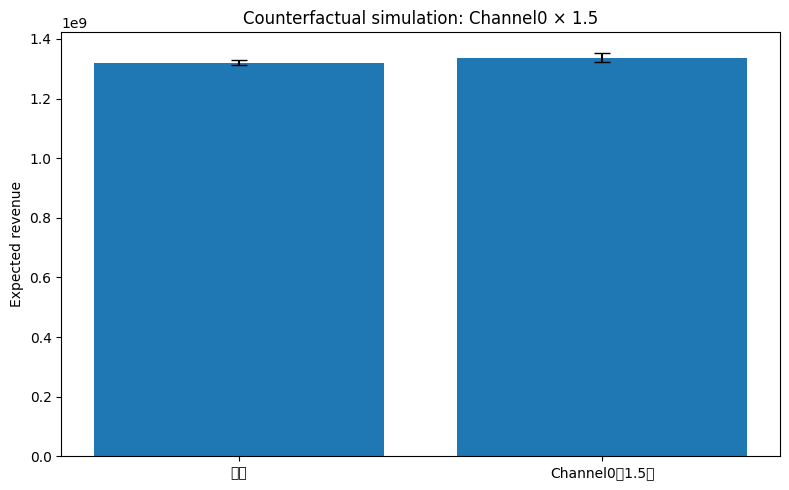

In [33]:
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(result))
means = result["expected_revenue_mean"].values
lower_error = means - result["ci_low"].values
upper_error = result["ci_high"].values - means

ax.bar(
    x,
    means,
    yerr=np.vstack([lower_error, upper_error]),
    capsize=6,
)

ax.set_xticks(x)
ax.set_xticklabels(result["scenario"])
ax.set_ylabel("Expected revenue")
ax.set_title(
    f"Counterfactual simulation: "
    f"{TARGET_CHANNEL} × {RATIO:.1f}"
)

plt.tight_layout()
plt.show()

### 解釈上の注意

この結果は、**対象チャネル以外の条件が変わらない**と仮定した反実仮想シミュレーションです。

実際に広告量を1.5倍へ増やした場合には、広告単価、配信在庫、クリエイティブ、競合状況なども変化する可能性があります。そのため、予測値を確定的な売上保証として扱うのではなく、意思決定のためのシナリオとして利用します。